In [7]:
import numpy as np
import matplotlib.pyplot as plt
import keras


### Load Dataset

In [6]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

### Affine Transform

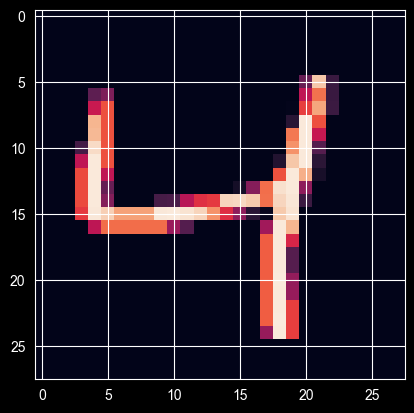

In [9]:
one_image = train_images[2]
plt.imshow(one_image)

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def affine_transform(image, matrix):
    h, w = image.shape
    transformed = np.zeros_like(image)
    inv_matrix = np.linalg.inv(matrix)
    cx = w / 2
    cy = h / 2
    for y in range(h):
        for x in range(w):
            coord = np.array([x - cx, y - cy, 1])
            src = inv_matrix @ coord
            sx = src[0] + cx
            sy = src[1] + cy
            sx = int(round(sx))
            sy = int(round(sy))
            if 0 <= sx < w and 0 <= sy < h:
                transformed[y, x] = image[sy, sx]
    return transformed

In [19]:
def translation(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=np.float32)

def rotation(theta_deg):
    t = np.radians(theta_deg)
    return np.array([
        [np.cos(t), -np.sin(t), 0],
        [np.sin(t),  np.cos(t), 0],
        [0, 0, 1]
    ], dtype=np.float32)

def scaling(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ], dtype=np.float32)

def shear(shx, shy):
    return np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ], dtype=np.float32)


transforms = [

    ("Rotate +45", rotation(45)),
    ("Rotate -45", rotation(-45)),
    ("Rotate +90", rotation(90)),
    ("Rotate -90", rotation(-90)),
    ("Rotate +180", rotation(-180)),

    ("Scale X", scaling(1.3, 1.0)),
    ("Scale Y", scaling(1.0, 1.3)),

    ("Shrink", scaling(0.7, 0.7)),

    ("Translate Right", translation(5, 0)),
    ("Translate Left", translation(-5, 0)),
    ("Translate Down", translation(0, 5)),

    ("Shear X", shear(0.4, 0.0)),
    ("Shear Y", shear(0.0, 0.4)),

    ("Combined A", translation(2, -2) @ rotation(25) @ scaling(0.8, 1.2)),
    ("Combined B", translation(2, -2) @ rotation(-45) @ scaling(0.8, 1.2))
]

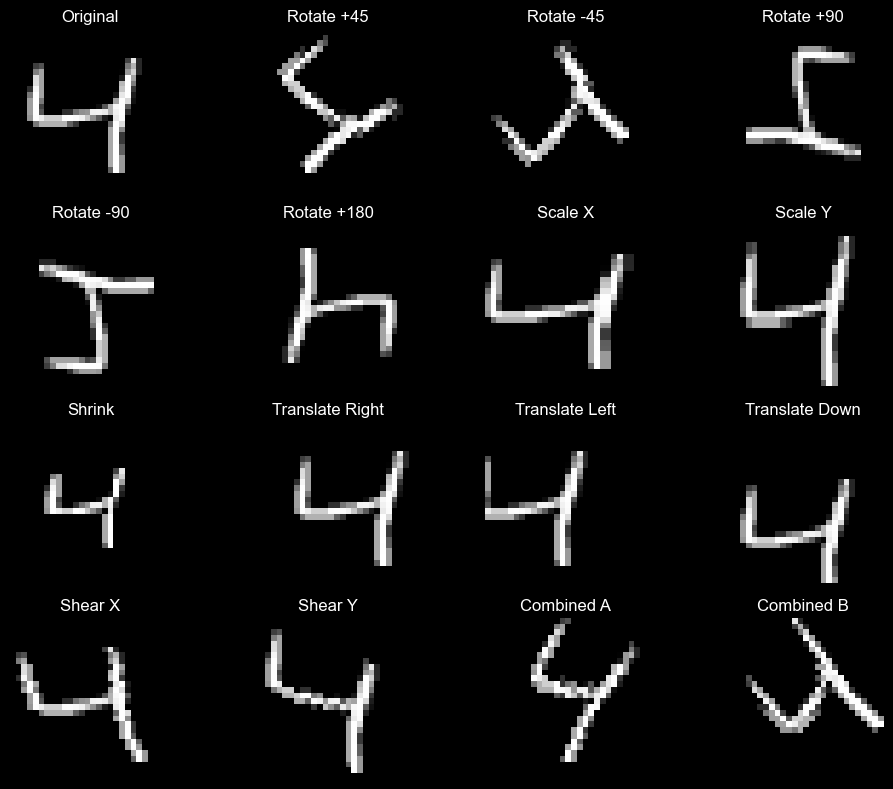

In [20]:
results = []

for name, mat in transforms:
    transformed = affine_transform(one_image, mat)
    results.append((name, transformed))

fig, axes = plt.subplots(4, 4, figsize=(10, 8))

axes = axes.flatten()

axes[0].imshow(one_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i, (name, result) in enumerate(results):
    axes[i + 1].imshow(result, cmap="gray")
    axes[i + 1].set_title(name)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

### Impute Affine into Mnist

In [21]:
train_images.shape

(60000, 28, 28)

In [ ]:
result_train_image = []
for i in train_images:
    for name, mat in transforms:
        transformed = affine_transform(i, mat)
        result_train_image.append((name, transformed))

len(result_train_image)